In [23]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold


# Exploration

In [24]:
DATA_DIR = "../data"

train_file = pd.read_csv(f"{DATA_DIR}/training_set_VU_DM.csv")
df_test = pd.read_csv(f"{DATA_DIR}/test_set_VU_DM.csv")

In [25]:
print(df.shape)
print(df_test.shape)

(4958347, 59)
(4959183, 50)


Plot style

In [26]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

## Read data

In [27]:
DATA_DIR = "../data"
train_file = os.path.join(DATA_DIR, 'training_set_VU_DM.csv')
test_file = os.path.join(DATA_DIR, 'test_set_VU_DM.csv')

train_df = pd.read_csv(train_file, parse_dates=['date_time'])
df = train_df.copy()
display(df.head())
df_test = pd.read_csv(test_file, parse_dates=['date_time'])

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


### Nulls

In [28]:
#df.columns.tolist()
df.isnull().sum()

srch_id                              0
date_time                            0
site_id                              0
visitor_location_country_id          0
visitor_hist_starrating        4706481
visitor_hist_adr_usd           4705359
prop_country_id                      0
prop_id                              0
prop_starrating                      0
prop_review_score                 7364
prop_brand_bool                      0
prop_location_score1                 0
prop_location_score2           1090348
prop_log_historical_price            0
position                             0
price_usd                            0
promotion_flag                       0
srch_destination_id                  0
srch_length_of_stay                  0
srch_booking_window                  0
srch_adults_count                    0
srch_children_count                  0
srch_room_count                      0
srch_saturday_night_bool             0
srch_query_affinity_score      4640941
orig_destination_distance

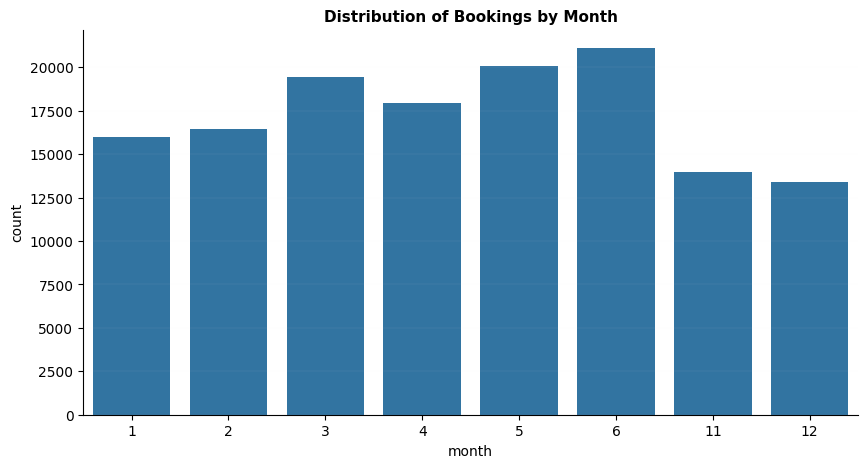

In [29]:
def get_datetime(data):
    data['month'] = data['date_time'].dt.month
    data['day_of_week'] = data['date_time'].dt.dayofweek
    data['hour'] = data['date_time'].dt.hour
    return data

df = get_datetime(df)

# booking distribution by month
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['booking_bool'] == 1], x='month')
plt.title('Distribution of Bookings by Month')
plt.show()

In [30]:
# % of missing values per column
missing_col_pct = (df.isnull().sum() / len(df)) * 100

# descending order sort
missing_col_pct = missing_col_pct.sort_values(ascending=False)

# only columns with some missing data
display(missing_col_pct[missing_col_pct > 0])

comp1_rate_percent_diff      98.095353
comp6_rate_percent_diff      98.060362
comp1_rate                   97.581250
comp1_inv                    97.387053
comp4_rate_percent_diff      97.356256
gross_bookings_usd           97.208949
comp7_rate_percent_diff      97.206428
comp6_rate                   95.156511
visitor_hist_starrating      94.920364
visitor_hist_adr_usd         94.897735
comp6_inv                    94.736633
comp4_rate                   93.800797
comp7_rate                   93.640058
srch_query_affinity_score    93.598552
comp4_inv                    93.069001
comp7_inv                    92.811677
comp3_rate_percent_diff      90.464625
comp2_rate_percent_diff      88.781786
comp8_rate_percent_diff      87.602118
comp5_rate_percent_diff      83.036706
comp3_rate                   69.056462
comp3_inv                    66.702814
comp8_rate                   61.344900
comp8_inv                    59.916016
comp2_rate                   59.166392
comp2_inv                

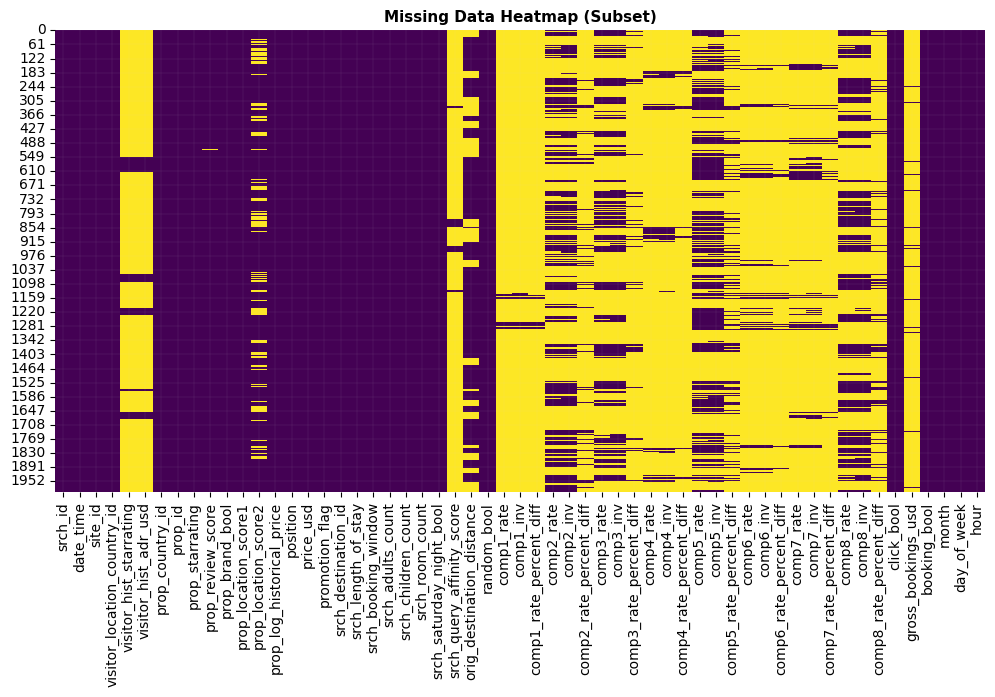

In [31]:
# visualise the first 1000 rows to see if missingness is clustered
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:2000].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Subset)")
plt.show()

interpretation: yellow is missing data, purple is where data is present. Where both columns are yellow - both feautres are not present.

In [32]:
# 1. Check if gross_bookings_usd is missing when booking_bool is 0
missing_logic = df.groupby('booking_bool')['gross_bookings_usd'].apply(lambda x: x.isnull().mean() * 100)
print(f"Percentage of missing 'gross_bookings_usd' by 'booking_bool':\n{missing_logic}")
print("---")

# 3. Analyze competitor rate sparsity
# Count how many competitor columns have data per row
comp_rate_cols = [c for c in df.columns if 'rate' in c and 'comp' in c]
df['comp_data_count'] = df[comp_rate_cols].notnull().sum(axis=1)
print(df['comp_data_count'].value_counts(normalize=True).sort_index())

Percentage of missing 'gross_bookings_usd' by 'booking_bool':
booking_bool
0    100.0
1      0.0
Name: gross_bookings_usd, dtype: float64
---
comp_data_count
0     3.462460e-01
1     7.305943e-02
2     1.286066e-01
3     1.444814e-01
4     1.432661e-01
5     5.926552e-02
6     5.984313e-02
7     1.687942e-02
8     2.440188e-02
9     1.307694e-03
10    2.058347e-03
11    1.968398e-04
12    3.872258e-04
13    4.033602e-07
Name: proportion, dtype: float64


Interpretation:
1. gross_bookings_usd - a 1:1 correlation: gross_bookings_usd is always missing when booking_bool is 0 (when the booking was not made)
Q: should we drop it?

3.

In [33]:
# Check if prop_review_score missingness correlates with position
# i.e. does a lack of reviews lead to lower search placement?
print(df.groupby(df['prop_review_score'].isnull())['position'].mean())
print("---")

prop_review_score
False    16.854939
True     17.728544
Name: position, dtype: float64
---


Interpretaiton: this shows little difference, however the logic assumes that all searched have around 35 resutls. VS. more meaningful would be analysing waht is the relative position of the property in the search and how does that compare with the review_score. So we check for relative ranks:

In [34]:
# 1. Calculate relative position per search session
df['rel_position'] = df.groupby('srch_id')['position'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0
)

# 2. Compare means
comparison = df.groupby(df['prop_review_score'].isnull())['rel_position'].mean()
print("Mean Relative Position (0 = Top, 1 = Bottom):")
print(comparison)

# 3. Significance Check (Delta)
delta = comparison[True] - comparison[False]
print(f"\nRanking Penalty for Missing Reviews: {delta:.4f}")

Mean Relative Position (0 = Top, 1 = Bottom):
prop_review_score
False    0.510327
True     0.622771
Name: rel_position, dtype: float64

Ranking Penalty for Missing Reviews: 0.1124


Interpretation: hat properties without a review score are, on average, ranked 11.24% lower in search results than those with reviews.

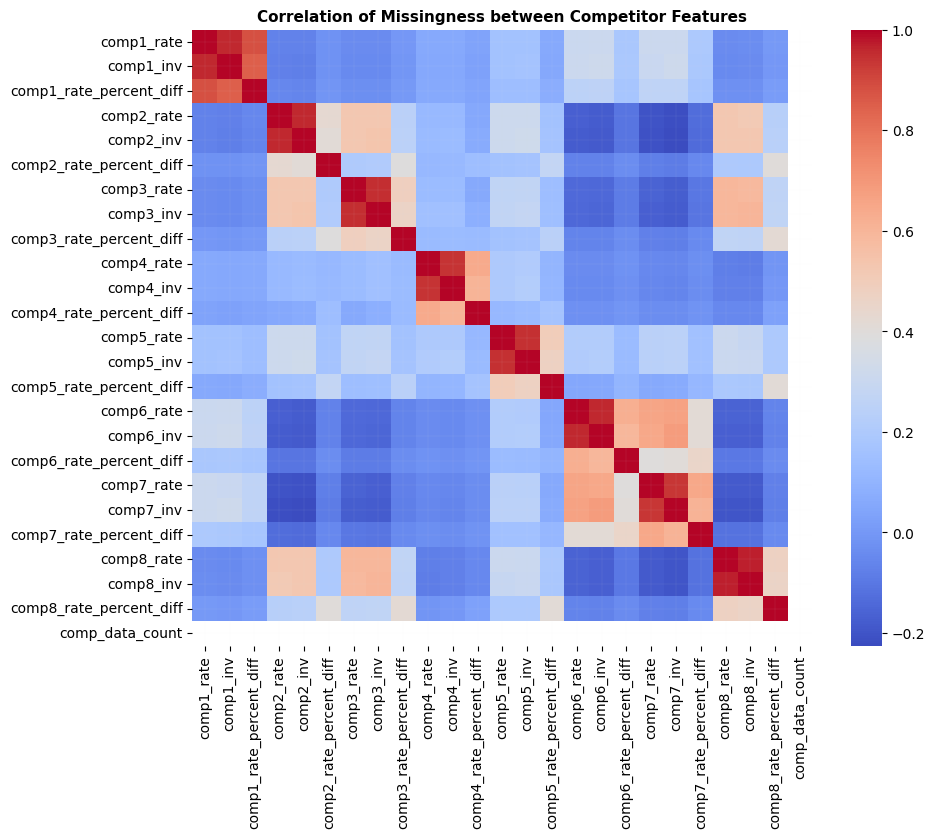

In [35]:
# check if competitor columns are missing simultaneously
comp_cols = [c for c in df.columns if 'comp' in c]
plt.figure(figsize=(10, 8))
sns.heatmap(df[comp_cols].isnull().corr(), annot=False, cmap='coolwarm')
plt.title("Correlation of Missingness between Competitor Features")
plt.show()

In [36]:
# List of highly sparse features from heatmap
sparse_cols = ['visitor_hist_starrating', 'srch_query_affinity_score', 'prop_location_score2']

for col in sparse_cols:
    # Check if the missingness correlates with the booking_bool
    correlation = df[col].isnull().corr(df['booking_bool'])
    print(f"Correlation between {col}_is_missing and booking_bool: {correlation:.4f}")

Correlation between visitor_hist_starrating_is_missing and booking_bool: -0.0115
Correlation between srch_query_affinity_score_is_missing and booking_bool: -0.0101
Correlation between prop_location_score2_is_missing and booking_bool: -0.0472


### Descriptive statistics

In [37]:
# Select numeric columns for statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate basic stats
stats = df[numeric_cols].describe().T.rename(columns={"50%": "median"})

# Calculate missing values
stats["missing"] = df[numeric_cols].isnull().sum()
stats["missing %"] = (stats["missing"] / len(df) * 100).round(1)

# Sort by missing % to identify problematic features (Task 3)
stats = stats.sort_values("missing %", ascending=False)
display(stats)

,count,mean,std,min,25%,median,75%,max,missing,missing %
comp1_rate_percent_diff,94439.0,244.229916,1165.448634,2.0000,7.000000,10.000000,16.000000,3.038900e+04,4863908,98.1
comp6_rate_percent_diff,96174.0,17.250473,31.160313,2.0000,6.000000,11.000000,18.000000,1.620000e+03,4862173,98.1
comp1_rate,119930.0,0.479788,0.641565,-1.0000,0.000000,1.000000,1.000000,1.000000e+00,4838417,97.6
comp1_inv,129559.0,0.031059,0.229688,-1.0000,0.000000,0.000000,0.000000,1.000000e+00,4828788,97.4
comp4_rate_percent_diff,131086.0,175.316533,5757.739837,2.0000,7.000000,11.000000,19.000000,1.001584e+06,4827261,97.4
comp7_rate_percent_diff,138515.0,19.433267,54.370221,2.0000,7.000000,12.000000,20.000000,9.900000e+03,4819832,97.2
gross_bookings_usd,138390.0,386.283316,821.190577,0.0000,124.000000,218.400000,429.790000,1.592924e+05,4819957,97.2
comp6_rate,240157.0,0.128329,0.559841,-1.0000,0.000000,0.000000,0.000000,1.000000e+00,4718190,95.2
visitor_hist_starrating,251866.0,3.374334,0.692519,1.4100,2.920000,3.450000,3.930000,5.000000e+00,4706481,94.9
visitor_hist_adr_usd,252988.0,176.022659,107.254493,0.0000,109.810000,152.240000,213.490000,1.958700e+03,4705359,94.9


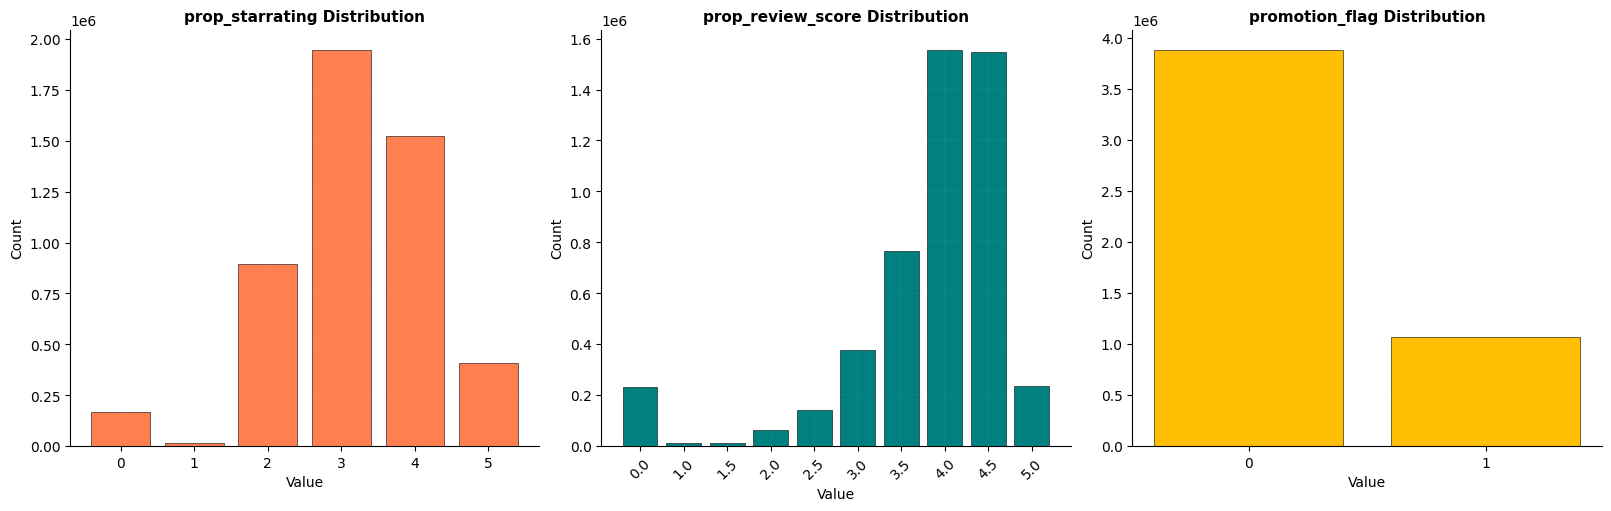

In [38]:
# plotting key variables identified from literature
important_vars = ["prop_starrating", "prop_review_score", "promotion_flag"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

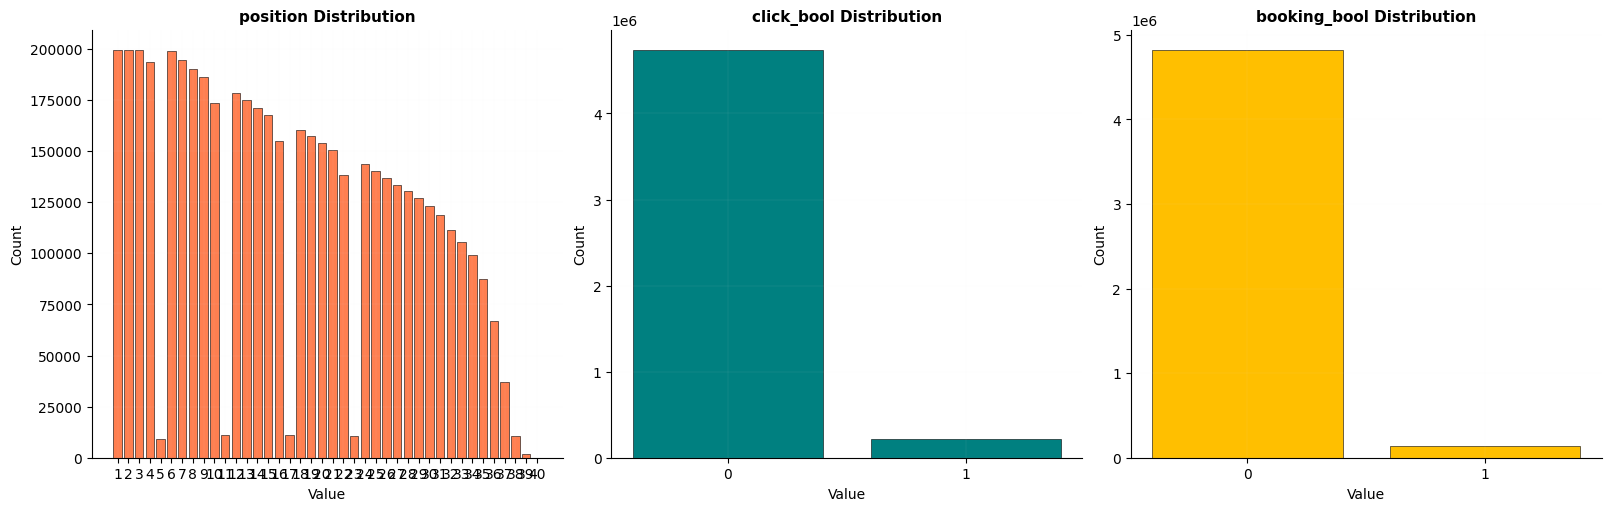

In [39]:
# target variables
# plotting key variables identified from literature
important_vars = ["position", "click_bool", "booking_bool"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

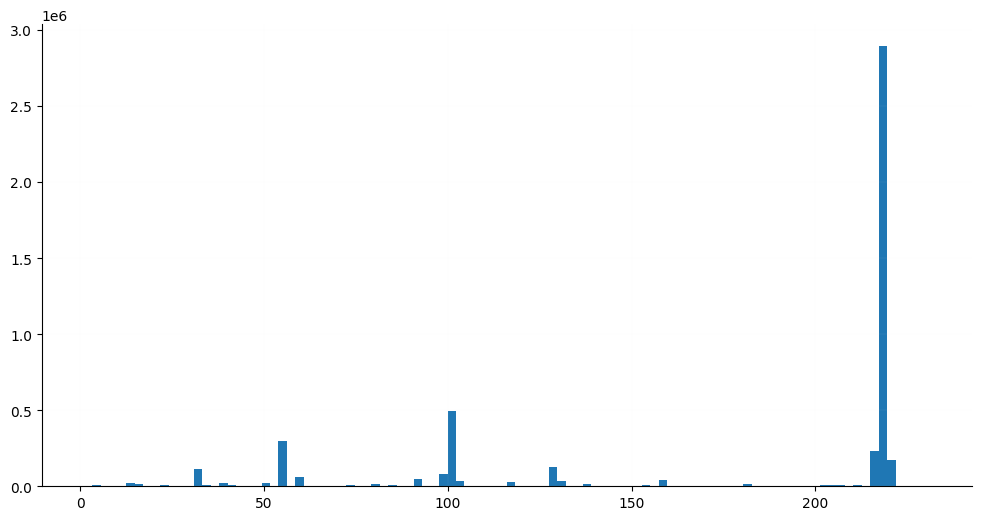

In [40]:
plt.figure(figsize=(12, 6))
plt.hist(df['visitor_location_country_id'], bins =100)
plt.show()

Conversion Rates by Saturday Night Stay:
   srch_saturday_night_bool  click_bool  booking_bool
0                         0    0.044510      0.027004
1                         1    0.044985      0.028809


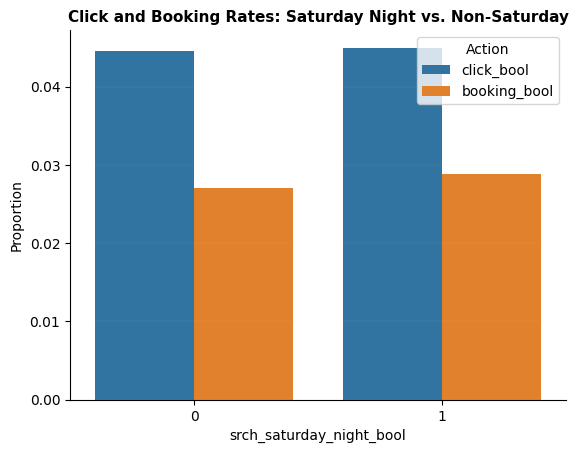

In [41]:
def explore_saturday_stay(data):
    """checking if Saturday night impacts the clicks and bookings"""
    # group by the boolean flag
    stats = data.groupby('srch_saturday_night_bool').agg({
        'click_bool': 'mean',
        'booking_bool': 'mean'
    }).reset_index()

    print("Conversion Rates by Saturday Night Stay:")
    print(stats)

    # plot
    stats_melted = stats.melt(id_vars='srch_saturday_night_bool', value_vars=['click_bool', 'booking_bool'], var_name='Action', value_name='Rate')

    sns.barplot(data=stats_melted, x='srch_saturday_night_bool', y='Rate', hue='Action')
    plt.title('Click and Booking Rates: Saturday Night vs. Non-Saturday')
    plt.ylabel('Proportion')
    plt.show()

explore_saturday_stay(df)

Adding the relevance column to align with the evaluation metric

In [42]:
# conditions
conditions = [
    (df['booking_bool'] == 1),
    (df['click_bool'] == 1)
]

# Define corresponding relevance grades
choices = [5, 1]

# Default to 0 if neither condition is met
df['relevance'] = np.select(conditions, choices, default=0)

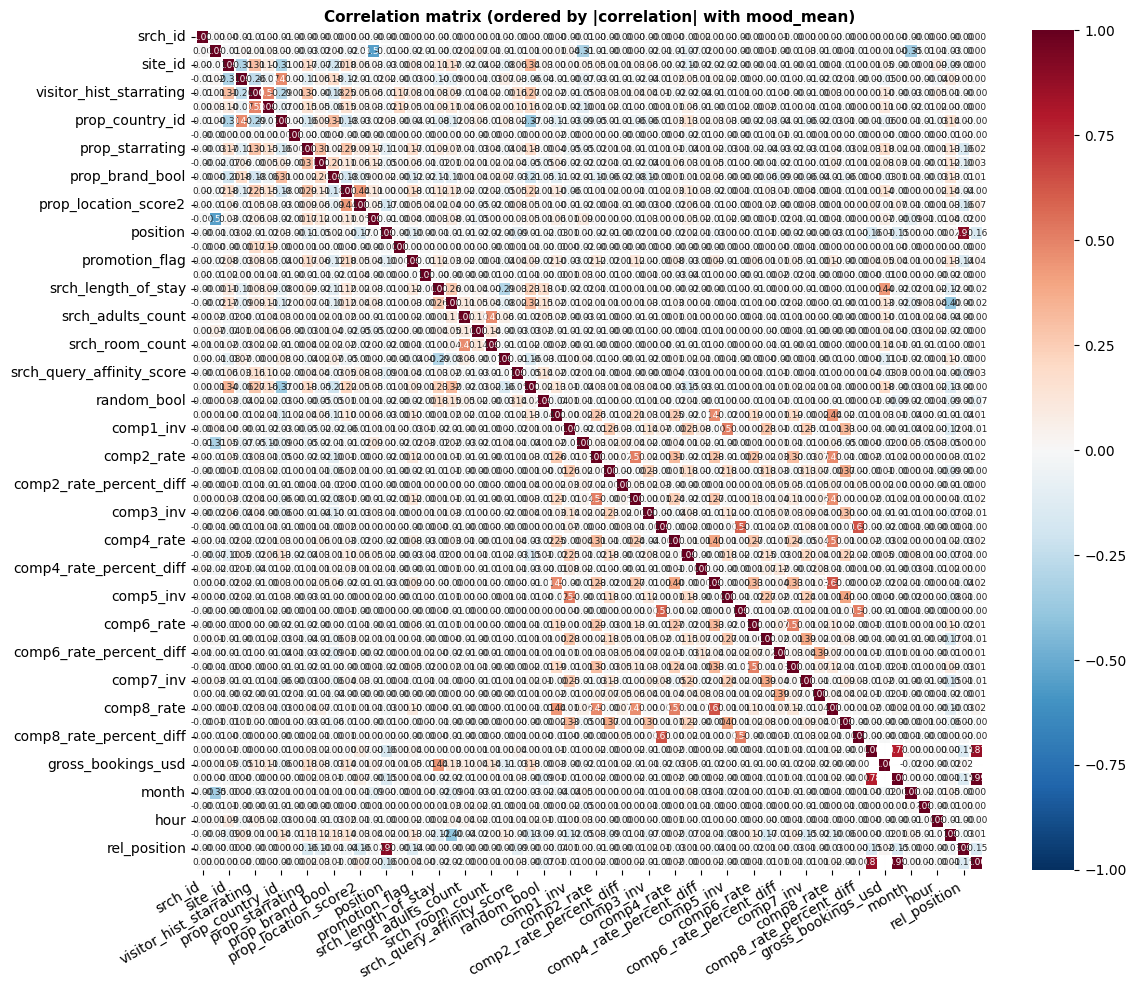

In [43]:
corr  = df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={"size": 6.5}, ax=ax)
ax.set_title("Correlation matrix (ordered by |correlation| with mood_mean)")
#plt.xticks(fontsize=7,rotation=40)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha="right")
plt.tight_layout()
#plt.savefig("figures/train_correlation_matrix.png", dpi=150)
plt.show()

In [44]:
print("Shape:", df.shape)
print("Unique users:", df["srch_id"].nunique())

Shape: (4958347, 60)
Unique users: 199795


### Promotion flag

In [45]:
# checking how the promotion flag correlates with the average position
promotion_stats = df.groupby('promotion_flag')['position'].mean().reset_index()

promotion_stats.columns = ['Promotion Flag', 'Average Position']
print(promotion_stats)

   Promotion Flag  Average Position
0               0         17.422649
1               1         14.795745


We see that the promotion flag means the average position is higher

In [46]:
# BIAS: we use Independent Samples T-Test to check if this difference is statistically significant - if algorithm promotes discounted hotels
from scipy import stats

# separate data into two groups
group_no_promo = df[df['promotion_flag'] == 0]['position']
group_promo = df[df['promotion_flag'] == 1]['position']

#Welch's T-test
t_stat, p_value = stats.ttest_ind(group_no_promo, group_promo, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant (Reject H0).")
else:
    print("The difference is not statistically significant (Fail to reject H0).")


T-statistic: 230.9399
P-value: 0.0000e+00
The difference is statistically significant (Reject H0).


Since the dataset is very large, even small differences result in a statistically significant result, as in here. we should mention that while statistically significant, the practical significance (the ~2.6 rank jump) is what truly influences the user's likelihood to click or book.

Read to see what are the options:
https://towardsdatascience.com/a-complete-guide-to-recommender-system-tutorial-with-sklearn-surprise-keras-recommender-5e52e8ceace1/

## K-Nearest Neighbours
https://www.geeksforgeeks.org/machine-learning/recommender-systems-using-knn/


In [47]:
# 1. Feature Selection (Intrinsic Properties)
features = [
    'prop_starrating', 'prop_review_score', 'prop_location_score1',
    'prop_location_score2', 'prop_log_historical_price',
    'price_usd', 'promotion_flag'
]

# 2. Preprocessing Pipeline
# Extract features and handle missing values/scaling
X = df[features].copy()
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Impute and Scale
X_processed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_processed)

# 3. Train-Test Split (80/20)
# Training set to find centroids; Test set to evaluate assignment stability
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# 4. Unsupervised Cross-Validation (Inertia Stability)
# We use K-Fold to ensure the clusters (Inertia) are consistent across different slices of data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_clusters = 50
cv_inertia = []

print(f"Starting 5-Fold Cross-Validation for K={k_clusters}...")

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]

    # Fit model on the fold training data
    km_fold = KMeans(n_clusters=k_clusters, n_init=5, random_state=42)
    km_fold.fit(X_fold_train)

    # Calculate Inertia on the validation fold
    # Inertia = sum of squared distances of samples to their closest cluster center
    cv_inertia.append(km_fold.inertia_)

print(f"Average CV Inertia: {np.mean(cv_inertia):.2f} (+/- {np.std(cv_inertia):.2f})")



Starting 5-Fold Cross-Validation for K=50...
Average CV Inertia: 2647813.22 (+/- 20324.80)


In [48]:
# 5. Final Model Implementation
# Fitting on the full training set and assigning clusters to the test set
final_kmeans = KMeans(n_clusters=k_clusters, n_init=10, random_state=42)
final_kmeans.fit(X_train)

# assign cluster labels back to the original dataframe for the test indices
train_indices, test_indices = train_test_split(df.index, test_size=0.2, random_state=42)
df.loc[train_indices, 'hotel_cluster'] = final_kmeans.labels_
df.loc[test_indices, 'hotel_cluster'] = final_kmeans.predict(X_test)

print("\nCluster assignment complete. Sample distribution:")
print(df['hotel_cluster'].value_counts().head())


Cluster assignment complete. Sample distribution:
hotel_cluster
17.0    309776
2.0     306708
40.0    294968
43.0    199867
23.0    198242
Name: count, dtype: int64


In [49]:
# 1. Generate the predicted rankings
# goal - list the PropertyIds for every SearchId sorted by their position or a calculated score

output_df = df[['srch_id', 'prop_id', 'position']].copy()

# Sort by SearchId (ascending) and Position (ascending) - ensures the 'best' properties for each search are listed first
output_df = output_df.sort_values(by=['srch_id', 'position'])

# 2. Rename columns to match required format
output_df = output_df.rename(columns={'srch_id': 'SearchId', 'prop_id': 'PropertyId'})

# 3. Drop the position column as it;s not needed
final_output = output_df[['SearchId', 'PropertyId']]

# 4. Display the first few rows
print(final_output.head(15).to_string(index=False))

# 5. Export to CSV (optional)
final_output.to_csv('expedia_recommendations.csv', index=False)

 SearchId  PropertyId
        1       95307
        1       74474
        1       53341
        1       29604
        1       89073
        1       30184
        1       88218
        1       56880
        1      107872
        1       68914
        1       81437
        1       44147
        1       59526
        1       59267
        1       21315


##